# Feature Signal + PCA Analysis

This notebook identifies feature signal against `target_y` and builds a numeric-feature PCA representation.

All fitting is done on train split only to reduce leakage risk.

In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

In [ ]:
# Try to ensure df_final exists in this notebook's own kernel.
csv_path = "df_final.csv"
try:
    df_final = pd.read_csv(csv_path)
except:
    print("Failed to load df_final.csv. Run data.ipynb first.")

if "target_y" not in df_final.columns:
    raise ValueError("`target_y` column is required in df_final.")

df_model = df_final.copy()
df_model["target_y"] = pd.to_numeric(df_model["target_y"], errors="coerce")
df_model = df_model.dropna(subset=["target_y"]).copy()
df_model["target_y"] = df_model["target_y"].astype(int)

leakage_cols = [
    "action_taken", "purchaser_type",
    "denial_reason-1", "denial_reason-2", "denial_reason-3", "denial_reason-4"
]
existing_leakage_cols = [c for c in leakage_cols if c in df_model.columns]
if existing_leakage_cols:
    df_model = df_model.drop(columns=existing_leakage_cols)

X = df_model.drop(columns=["target_y"])
y = df_model["target_y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in numeric_cols]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(cat_cols))

Train shape: (111992, 53)
Test shape: (27999, 53)
Numeric columns: 40
Categorical columns: 13


In [14]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Bias-corrected Cramer's V for categorical association."""
    valid = pd.DataFrame({"x": x, "y": y}).dropna()
    if valid.empty:
        return np.nan

    confusion = pd.crosstab(valid["x"], valid["y"])
    if confusion.empty or confusion.shape[0] < 2 or confusion.shape[1] < 2:
        return np.nan

    chi2 = stats.chi2_contingency(confusion)[0]
    n = confusion.values.sum()
    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = confusion.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((k_corr - 1), (r_corr - 1))
    if denom <= 0:
        return np.nan

    return float(np.sqrt(phi2_corr / denom))


def safe_pointbiserial(feature: pd.Series, target: pd.Series):
    valid = pd.DataFrame({"x": feature, "y": target}).dropna()
    if valid["x"].nunique() < 2:
        return np.nan, np.nan
    r, p = stats.pointbiserialr(valid["y"], valid["x"])
    return float(r), float(p)

In [15]:
# 1) Signal feature discovery vs target_y

# Numeric associations: point-biserial + spearman
num_rows = []
for col in numeric_cols:
    r_pb, p_pb = safe_pointbiserial(X_train[col], y_train)
    spear = pd.DataFrame({"x": X_train[col], "y": y_train}).dropna()
    if spear["x"].nunique() > 1:
        r_sp, p_sp = stats.spearmanr(spear["x"], spear["y"])
    else:
        r_sp, p_sp = (np.nan, np.nan)

    num_rows.append({
        "feature": col,
        "pointbiserial_r": r_pb,
        "pointbiserial_p": p_pb,
        "spearman_r": float(r_sp) if pd.notna(r_sp) else np.nan,
        "spearman_p": float(p_sp) if pd.notna(p_sp) else np.nan,
        "abs_pointbiserial_r": abs(r_pb) if pd.notna(r_pb) else np.nan,
    })

numeric_signal = (
    pd.DataFrame(num_rows)
    .sort_values("abs_pointbiserial_r", ascending=False)
    .reset_index(drop=True)
)

# Categorical associations: Cramer's V + MI
cat_rows = []
if cat_cols:
    # Prepare ordinal codes for MI only (train-fit only via categories from train)
    X_cat_train = X_train[cat_cols].copy()
    for c in cat_cols:
        X_cat_train[c] = X_cat_train[c].astype("category")

    X_cat_codes = np.column_stack([
        X_cat_train[c].cat.codes.replace(-1, np.nan).fillna(-1).astype(int).values
        for c in cat_cols
    ])
    mi_vals = mutual_info_classif(X_cat_codes, y_train.values, discrete_features=True, random_state=42)

    for i, col in enumerate(cat_cols):
        cat_rows.append({
            "feature": col,
            "cramers_v": cramers_v(X_train[col], y_train),
            "mutual_info": float(mi_vals[i]),
        })

categorical_signal = (
    pd.DataFrame(cat_rows)
    .sort_values(["cramers_v", "mutual_info"], ascending=False)
    .reset_index(drop=True)
    if cat_rows else pd.DataFrame(columns=["feature", "cramers_v", "mutual_info"])
)

print("Top numeric signal features")
display(numeric_signal.head(20))

print("Top categorical signal features")
display(categorical_signal.head(20))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.Consta

Top numeric signal features


,feature,pointbiserial_r,pointbiserial_p,spearman_r,spearman_p,abs_pointbiserial_r
0,hoepa_status,-0.784709,0.000000e+00,-0.785348,0.000000e+00,0.784709
1,lien_status,-0.216742,0.000000e+00,-0.216742,0.000000e+00,0.216742
2,construction_method,-0.201593,0.000000e+00,-0.201593,0.000000e+00,0.201593
3,is_joint_application,0.087497,3.515391e-189,0.087497,3.515391e-189,0.087497
4,co-applicant_race_observed,-0.081675,4.973181e-165,-0.082515,2.073924e-168,0.081675
5,co-applicant_sex_observed,-0.081481,2.994019e-164,-0.082355,9.244407e-168,0.081481
6,co-applicant_ethnicity_observed,-0.081419,5.255700e-164,-0.082274,1.957899e-167,0.081419
7,tract_to_msa_income_percentage,0.081333,1.161807e-163,0.083198,3.474824e-171,0.081333
8,preapproval,-0.064860,1.113000e-104,-0.064860,1.113000e-104,0.064860
9,loan_type,0.053825,1.230494e-72,0.050931,3.205642e-65,0.053825


Top categorical signal features


,feature,cramers_v,mutual_info
0,aus_grouped,0.306087,0.045292
1,loan_purpose_grouped,0.257823,0.027730
2,loan_product_grouped,0.216688,0.020004
3,derived_dwelling_category,0.202698,0.016022
4,manufactured_home_grouped,0.202162,0.015788
5,covid_phase,0.107610,0.005744
6,derived_ethnicity,0.086251,0.003589
7,derived_sex,0.083659,0.003582
8,applicant_age_grouped,0.058749,0.002085
9,state_code,0.050353,0.001262


Highly redundant numeric pairs (|Spearman| >= 0.8)


,feature_1,feature_2,spearman_corr,abs_corr
696,co-applicant_race_observed,co-applicant_sex_observed,0.998389,0.998389
669,co-applicant_ethnicity_observed,co-applicant_race_observed,0.998319,0.998319
671,co-applicant_ethnicity_observed,co-applicant_sex_observed,0.998062,0.998062
727,co-applicant_sex_observed,is_joint_application,-0.983711,0.983711
706,co-applicant_race_observed,is_joint_application,-0.983270,0.983270
681,co-applicant_ethnicity_observed,is_joint_application,-0.982864,0.982864
654,applicant_ethnicity_observed,applicant_race_observed,0.973265,0.973265
683,applicant_race_observed,applicant_sex_observed,0.967503,0.967503
656,applicant_ethnicity_observed,applicant_sex_observed,0.964747,0.964747
767,tract_owner_occupied_units,tract_one_to_four_family_homes,0.896086,0.896086


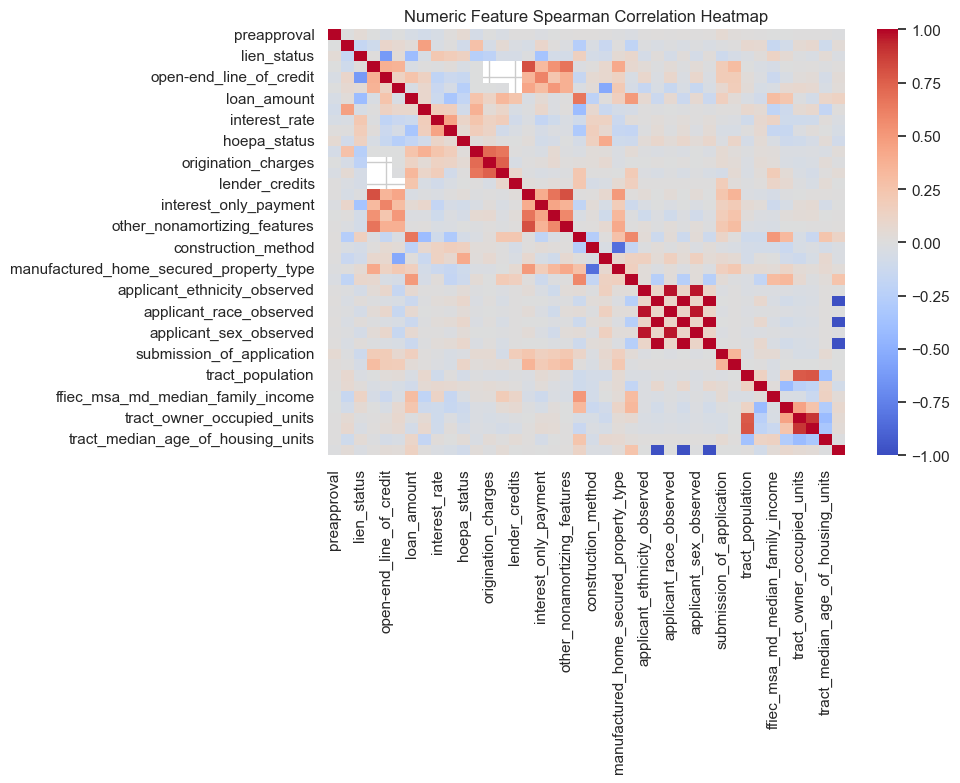

In [16]:
# 2) Redundancy check among numeric predictors (train only)

if numeric_cols:
    corr_spearman = X_train[numeric_cols].corr(method="spearman")

    corr_long = (
        corr_spearman.where(np.triu(np.ones(corr_spearman.shape), k=1).astype(bool))
        .stack()
        .reset_index()
    )
    corr_long.columns = ["feature_1", "feature_2", "spearman_corr"]
    corr_long["abs_corr"] = corr_long["spearman_corr"].abs()

    high_corr_pairs = corr_long[corr_long["abs_corr"] >= 0.8].sort_values("abs_corr", ascending=False)

    print("Highly redundant numeric pairs (|Spearman| >= 0.8)")
    display(high_corr_pairs.head(30))

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_spearman, cmap="coolwarm", center=0, vmin=-1, vmax=1)
    plt.title("Numeric Feature Spearman Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    corr_spearman = pd.DataFrame()
    high_corr_pairs = pd.DataFrame(columns=["feature_1", "feature_2", "spearman_corr", "abs_corr"])
    print("No numeric columns available for redundancy check.")

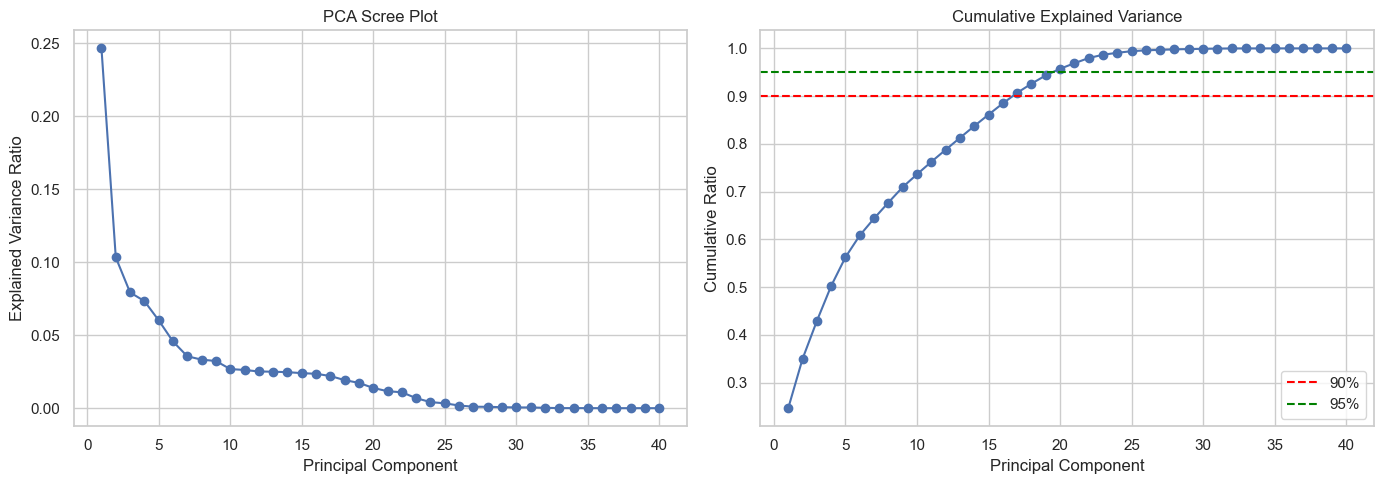

PCA components for >=90% variance: 17
PCA components for >=95% variance: 20


,component,feature,loading
0,PC1,open-end_line_of_credit,0.316837
1,PC1,reverse_mortgage,0.316836
2,PC1,manufactured_home_secured_property_type,0.316698
3,PC1,initially_payable_to_institution,0.316090
4,PC1,submission_of_application,0.316086
5,PC1,negative_amortization,0.315196
6,PC1,other_nonamortizing_features,0.315196
7,PC1,interest_only_payment,0.315194
8,PC1,balloon_payment,0.315194
9,PC1,business_or_commercial_purpose,0.314183


In [17]:
# 3) Unsupervised path A: Numeric PCA

if numeric_cols:
    num_imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    X_num_train = num_imputer.fit_transform(X_train[numeric_cols])
    X_num_test = num_imputer.transform(X_test[numeric_cols])

    X_num_train_scaled = scaler.fit_transform(X_num_train)
    X_num_test_scaled = scaler.transform(X_num_test)

    pca_full = PCA(random_state=42)
    pca_full.fit(X_num_train_scaled)

    cum_var = np.cumsum(pca_full.explained_variance_ratio_)
    n90 = int(np.argmax(cum_var >= 0.90) + 1)
    n95 = int(np.argmax(cum_var >= 0.95) + 1)

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(range(1, len(pca_full.explained_variance_ratio_) + 1), pca_full.explained_variance_ratio_, marker="o")
    ax[0].set_title("PCA Scree Plot")
    ax[0].set_xlabel("Principal Component")
    ax[0].set_ylabel("Explained Variance Ratio")

    ax[1].plot(range(1, len(cum_var) + 1), cum_var, marker="o")
    ax[1].axhline(0.90, color="red", linestyle="--", label="90%")
    ax[1].axhline(0.95, color="green", linestyle="--", label="95%")
    ax[1].set_title("Cumulative Explained Variance")
    ax[1].set_xlabel("Principal Component")
    ax[1].set_ylabel("Cumulative Ratio")
    ax[1].legend()
    plt.tight_layout()
    plt.show()

    print(f"PCA components for >=90% variance: {n90}")
    print(f"PCA components for >=95% variance: {n95}")

    pca_95 = PCA(n_components=n95, random_state=42)
    X_train_pca = pca_95.fit_transform(X_num_train_scaled)
    X_test_pca = pca_95.transform(X_num_test_scaled)

    loading_df = pd.DataFrame(
        pca_95.components_.T,
        index=numeric_cols,
        columns=[f"PC{i+1}" for i in range(pca_95.n_components_)]
    )

    top_loading_rows = []
    for pc in loading_df.columns[: min(5, loading_df.shape[1])]:
        top = loading_df[pc].abs().sort_values(ascending=False).head(10).index.tolist()
        for feat in top:
            top_loading_rows.append({"component": pc, "feature": feat, "loading": loading_df.loc[feat, pc]})

    top_pca_loadings = pd.DataFrame(top_loading_rows)
    display(top_pca_loadings)
else:
    n90 = n95 = 0
    X_train_pca = X_test_pca = None
    loading_df = pd.DataFrame()
    top_pca_loadings = pd.DataFrame(columns=["component", "feature", "loading"])
    print("No numeric columns available for PCA.")

In [19]:
# 4) Modeling-phase handoff artifacts

top_numeric_features = numeric_signal["feature"].head(25).tolist() if not numeric_signal.empty else []
top_categorical_features = categorical_signal["feature"].head(25).tolist() if not categorical_signal.empty else []

recommendations = {
    "top_numeric_features": top_numeric_features,
    "top_categorical_features": top_categorical_features,
    "high_corr_numeric_pairs_count": int(len(high_corr_pairs)) if "high_corr_pairs" in globals() else 0,
    "pca_components_90": int(n90) if "n90" in globals() else None,
    "pca_components_95": int(n95) if "n95" in globals() else None,
}

recommendations_df = pd.DataFrame([recommendations])
display(recommendations_df)

# Optional outputs for downstream modeling cells/files
outputs = {
    "numeric_signal": numeric_signal,
    "categorical_signal": categorical_signal,
    "high_corr_pairs": high_corr_pairs,
    "top_pca_loadings": top_pca_loadings,
    "X_train_pca": X_train_pca,
    "X_test_pca": X_test_pca,
}

print("Prepared modeling handoff artifacts:")
print(list(outputs.keys()))

,top_numeric_features,top_categorical_features,high_corr_numeric_pairs_count,pca_components_90,pca_components_95
0,"[hoepa_status, lien_status, construction_metho...","[aus_grouped, loan_purpose_grouped, loan_produ...",13,17,20


Prepared modeling handoff artifacts:
['numeric_signal', 'categorical_signal', 'high_corr_pairs', 'top_pca_loadings', 'X_train_pca', 'X_test_pca']
